In [75]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# set directory to parent directory
os.chdir("/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae")

# print current working directory
print("Current Working Directory:", os.getcwd())


Current Working Directory: /Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae


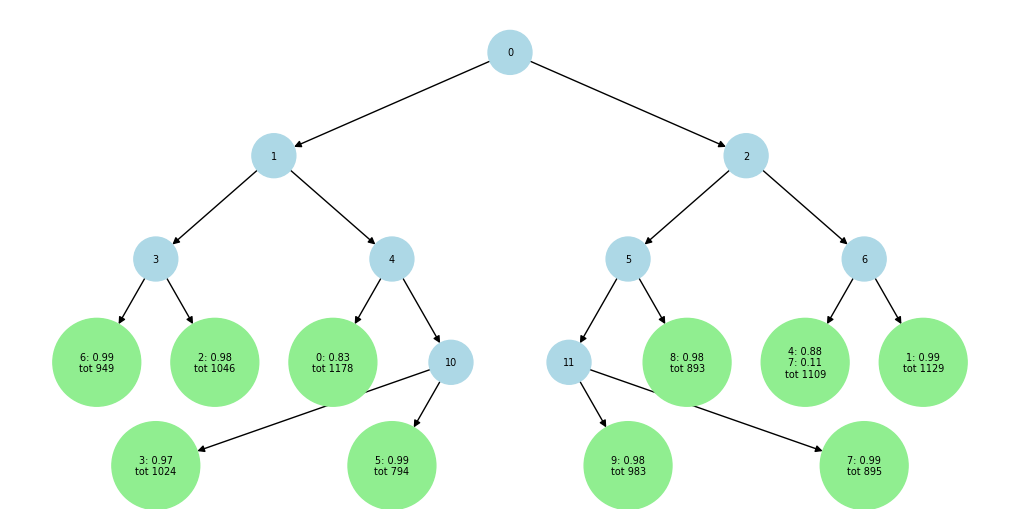

In [88]:
from utils.plotting_utils import plot_tree_graph

path = '/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae/models/experiments/'

dataset = 'cifar10'
ex_name = '/20240307-195731_9e95e'

dataset = 'mnist'
ex_name = '/20240308-131511_3da26'

#dataset = 'fmnist'
#ex_name = '/20240301-204616_da161'

checkpoint_path = path+dataset+ex_name
data_tree = np.load(checkpoint_path+'/data_tree.npy', allow_pickle=True)

plot_tree_graph(data_tree)


In [89]:
vae_samples_dir = "../from_cluster/results_all_leaves/" + dataset + "/seed_1/vae/sample_all_leaves"
ddpm_samples_dir = "../from_cluster/results_all_leaves/" + dataset + "/seed_1/ddpm/sample_all_l"

In [90]:
max_rank = 0
max_batch_idx = 0
max_sample_idx = 10

rank 0, batch_idx 0, sample_idx 0


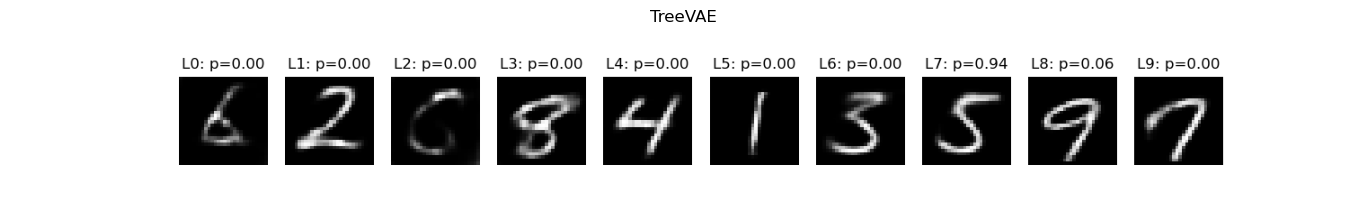

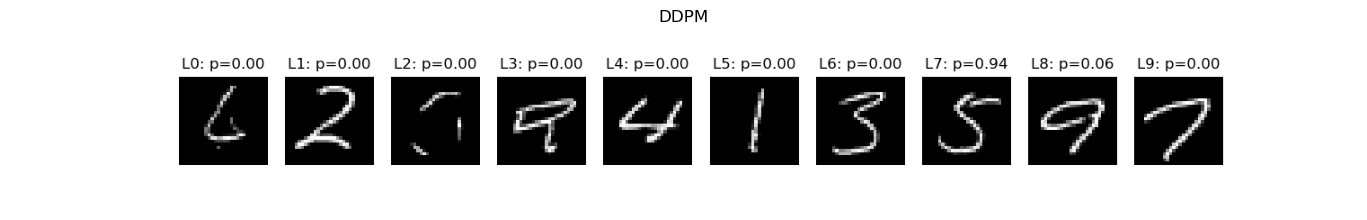

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 1


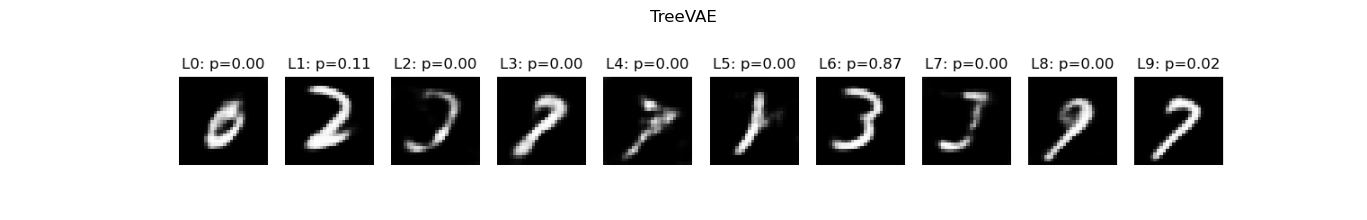

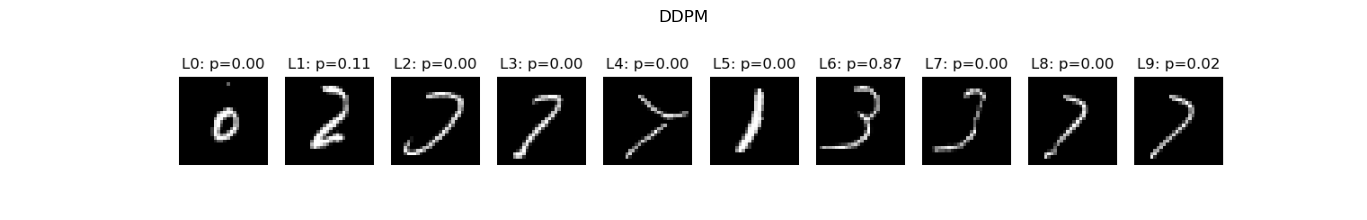

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 2


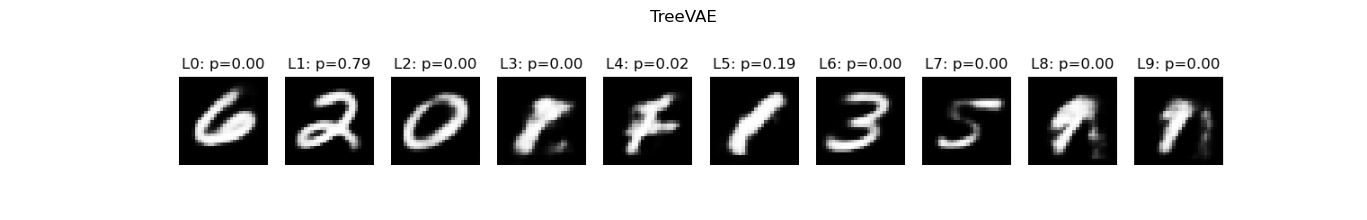

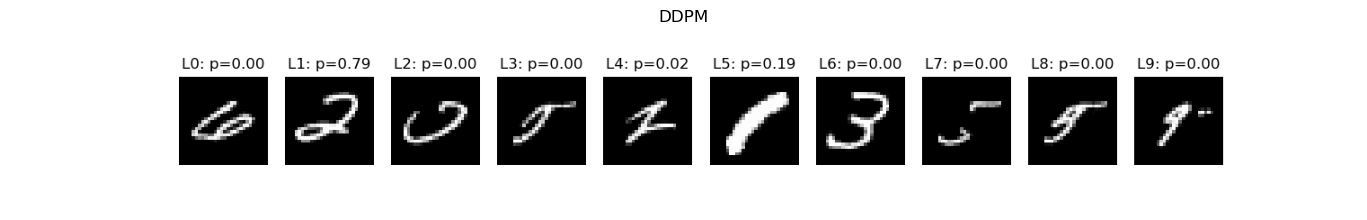

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 3


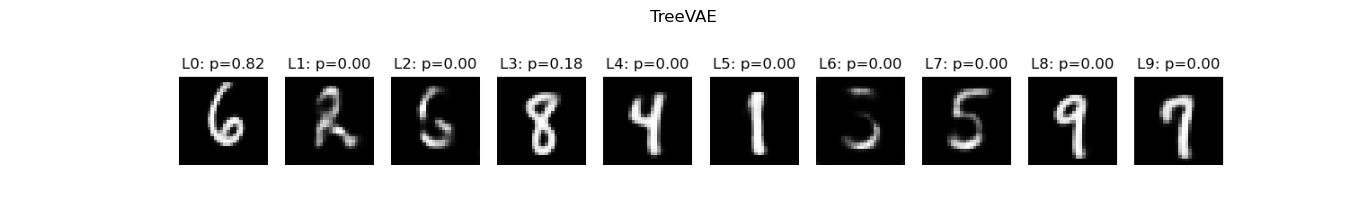

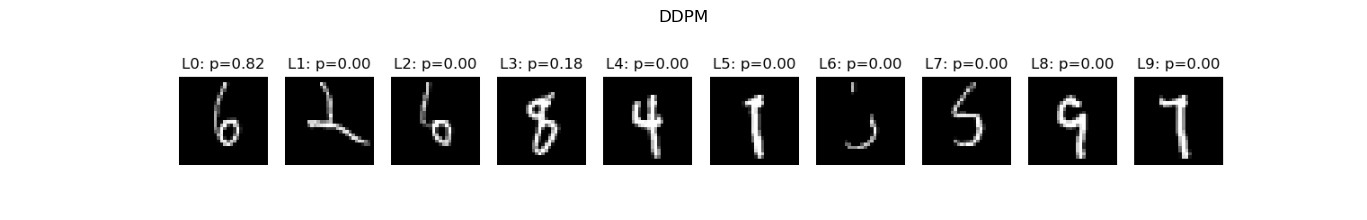

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 4


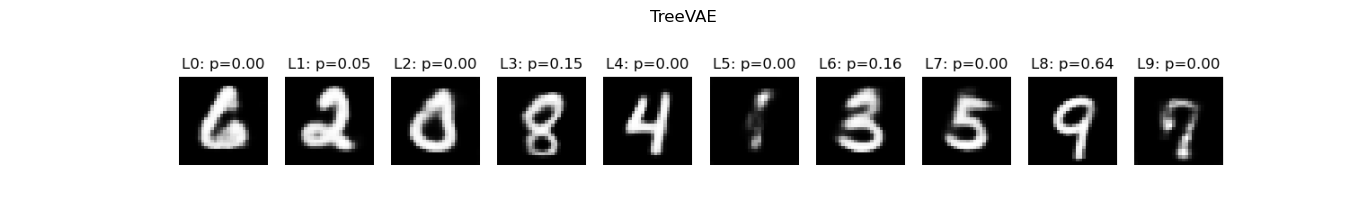

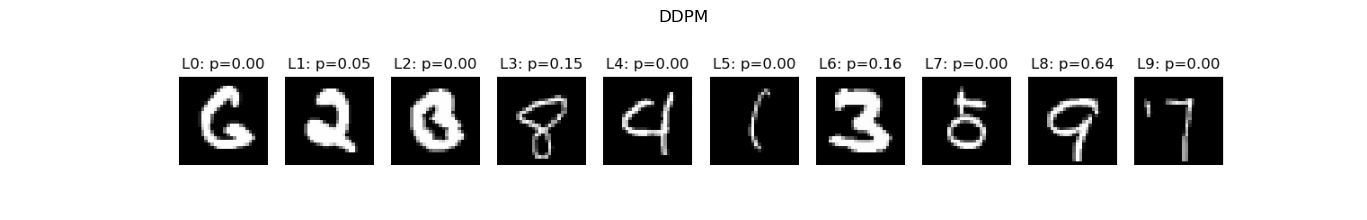

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 5


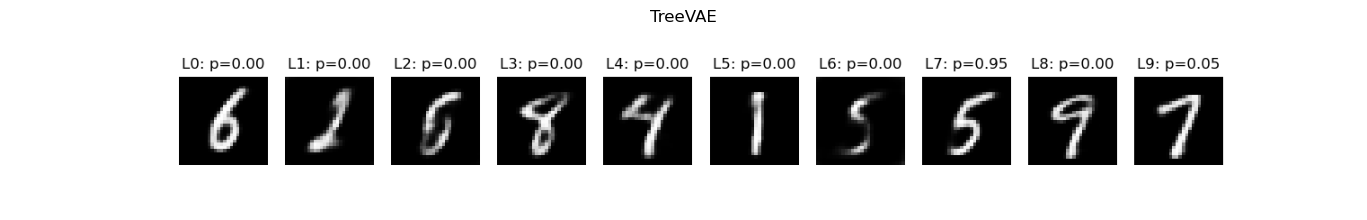

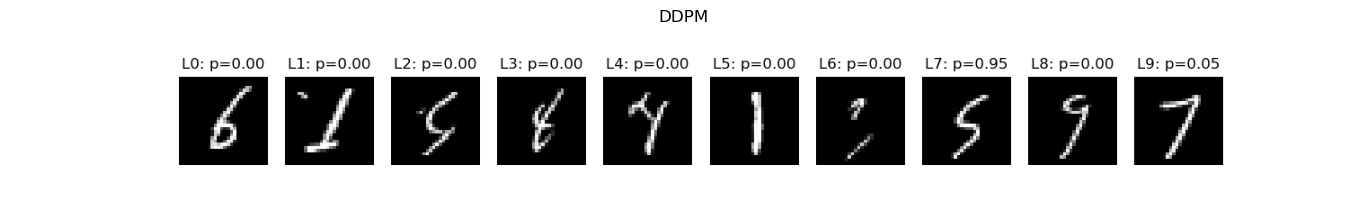

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 6


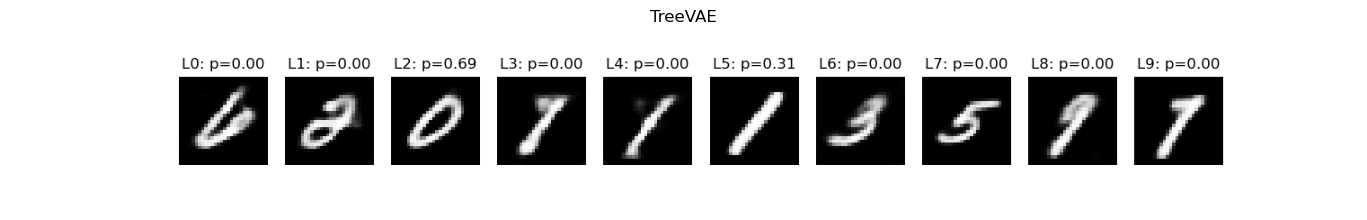

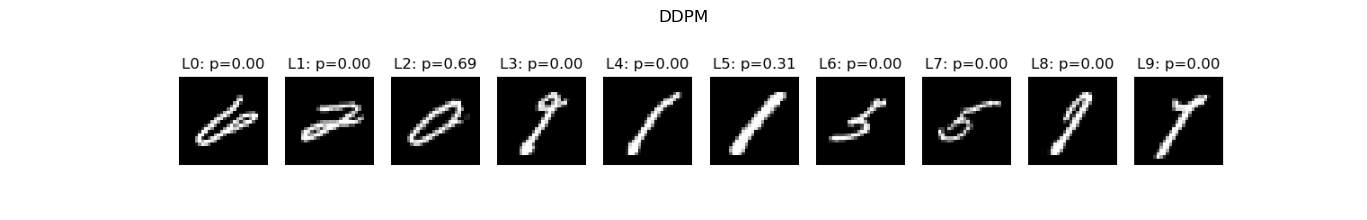

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 7


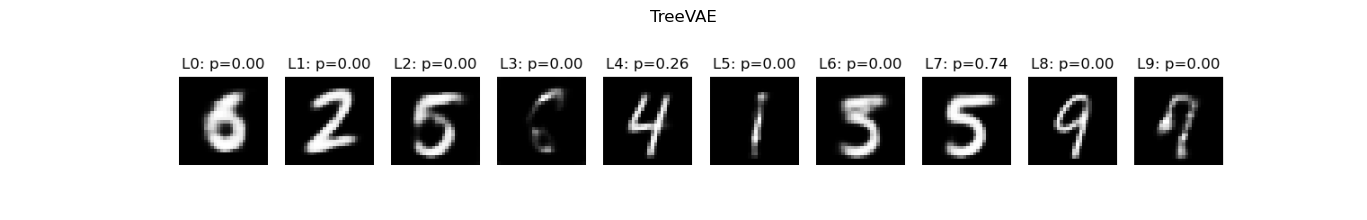

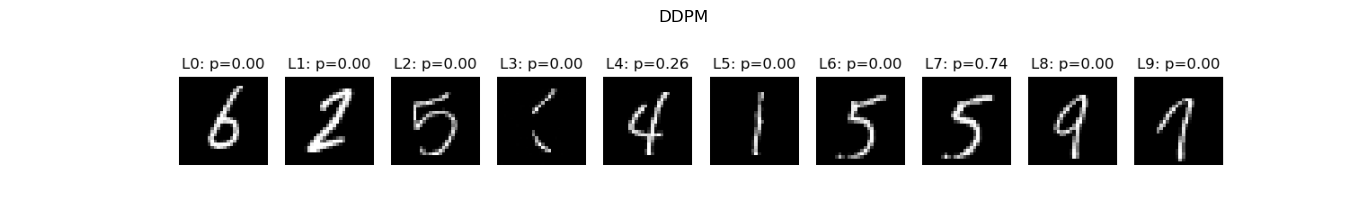

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 8


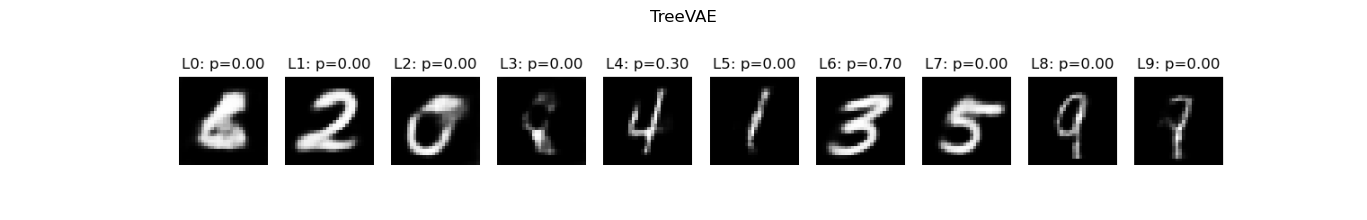

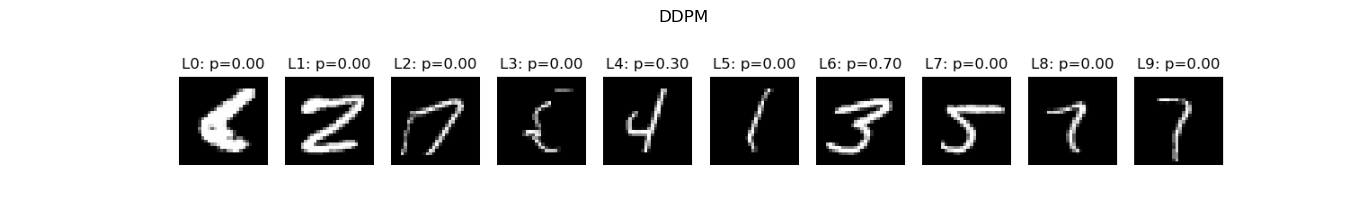

------------------------------------------------------------------------------------------------------------------------------------------------------
rank 0, batch_idx 0, sample_idx 9


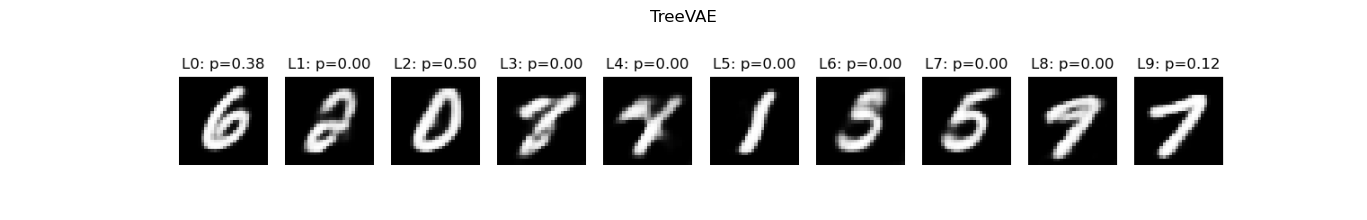

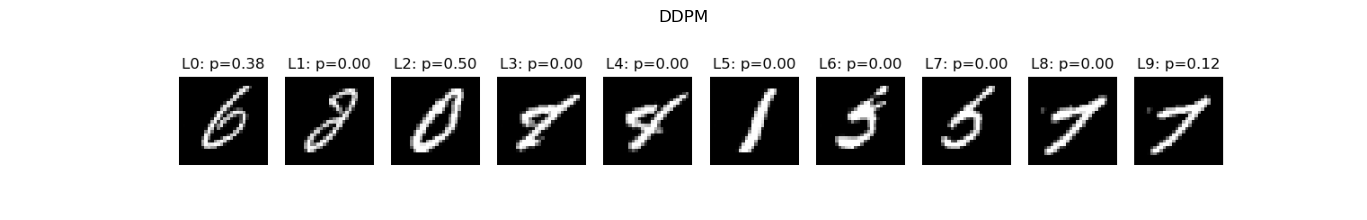

------------------------------------------------------------------------------------------------------------------------------------------------------


In [91]:
# show vae samples and ddpm samples

for rank in range(max_rank+1):
    for batch_idx in range(max_batch_idx+1):
        for sample_idx in range(max_sample_idx):
            print(f"rank {rank}, batch_idx {batch_idx}, sample_idx {sample_idx}")
            vae_filename = f"output_vae__{rank}_{batch_idx}_{sample_idx}.png"
            ddpm_filename = f"output__{rank}_{batch_idx}_{sample_idx}.png"

            # display vae sample, no axis
            vae_img = mpimg.imread(os.path.join(vae_samples_dir, vae_filename))
            plt.figure(figsize=(15,2))
            plt.imshow(vae_img)
            plt.axis("off")
            plt.title("TreeVAE")
            plt.tight_layout(pad=0)
            plt.show()

            # display ddpm sample
            ddpm_img = mpimg.imread(os.path.join(ddpm_samples_dir, ddpm_filename))
            plt.figure(figsize=(15,2))
            plt.imshow(ddpm_img)
            plt.axis("off")
            plt.title("DDPM")
            plt.tight_layout(pad=0)
            plt.show()

            print(150*"-")


# Clusters with images of high probability 


In [92]:
# get max class_id from the "../from_cluster/results_all_leaves/cifar10/seed_1/ddpm/sample_all_l/img_cluster_{cluster_id}/" folder

max_cluster_id = 0

for filename in os.listdir(f"../from_cluster/results_all_leaves/{dataset}/seed_1/ddpm/sample_all_l/"):
    if filename.startswith("img_cluster_"):
        cluster_id = int(filename.split("_")[2])
        if cluster_id > max_cluster_id:
            max_cluster_id = cluster_id

cluster_id 0


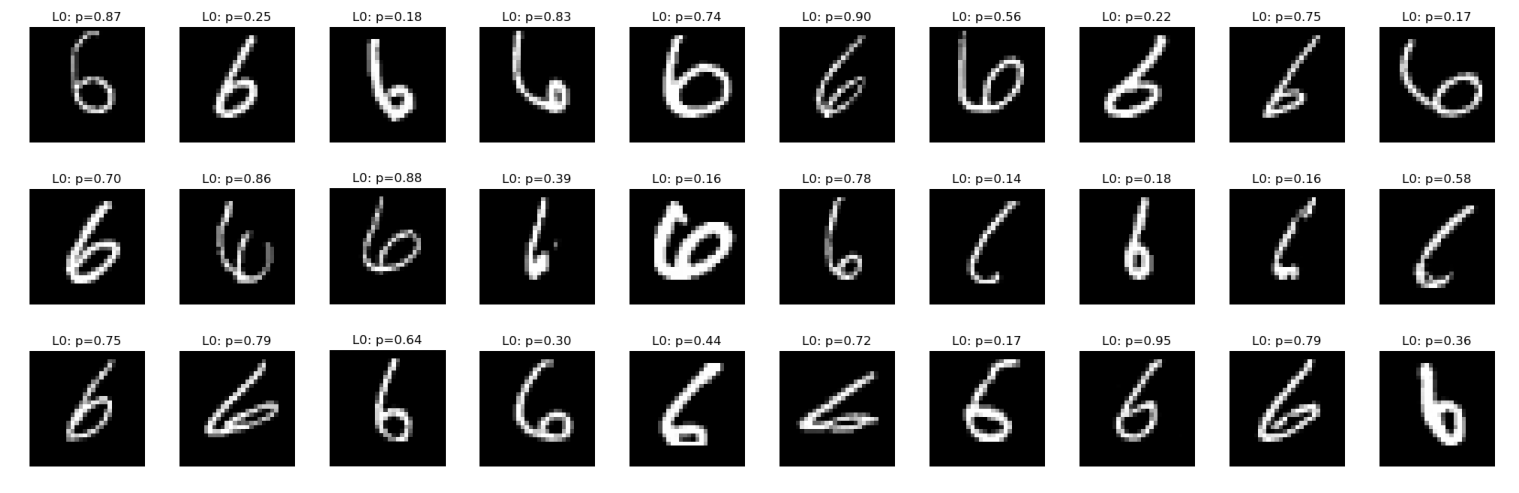

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 1


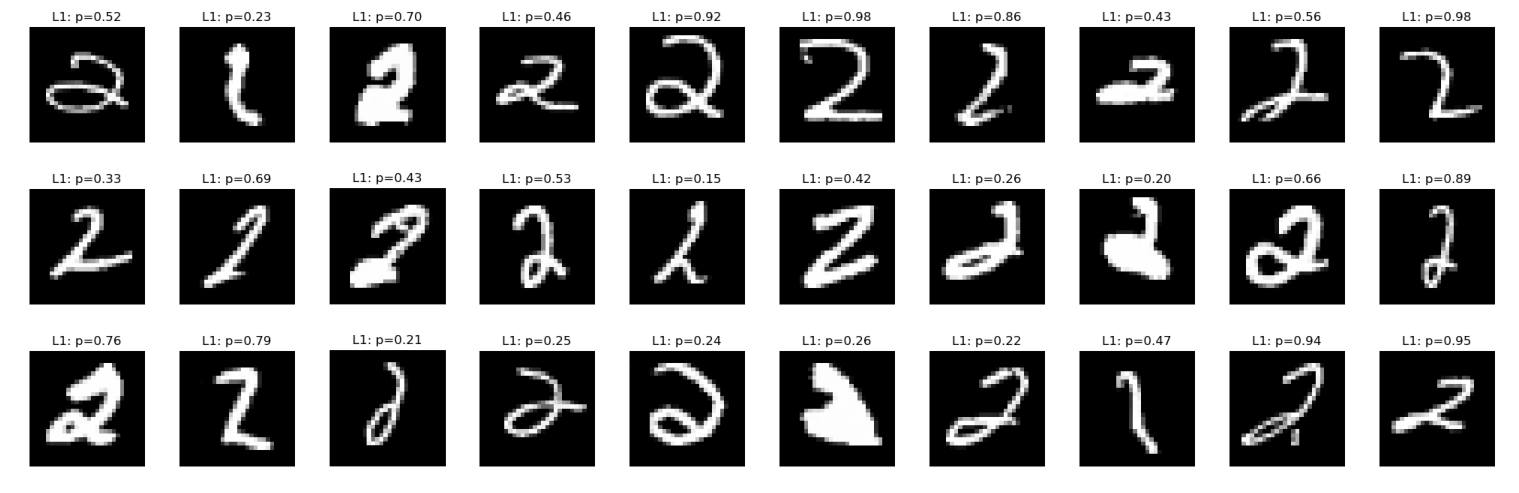

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 2


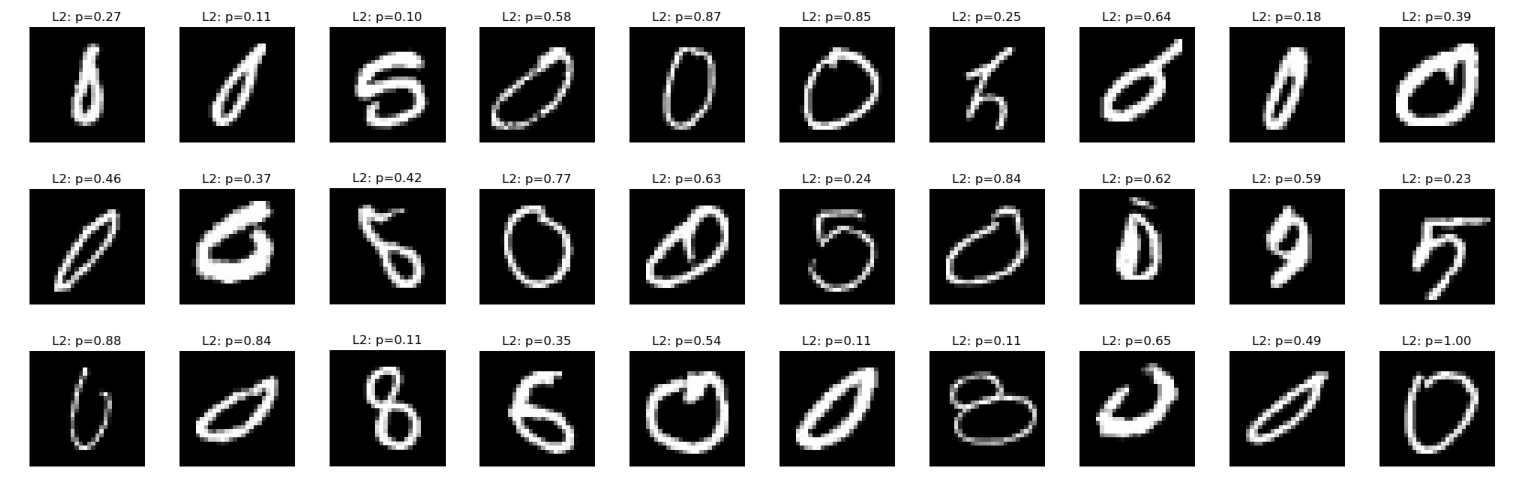

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 3


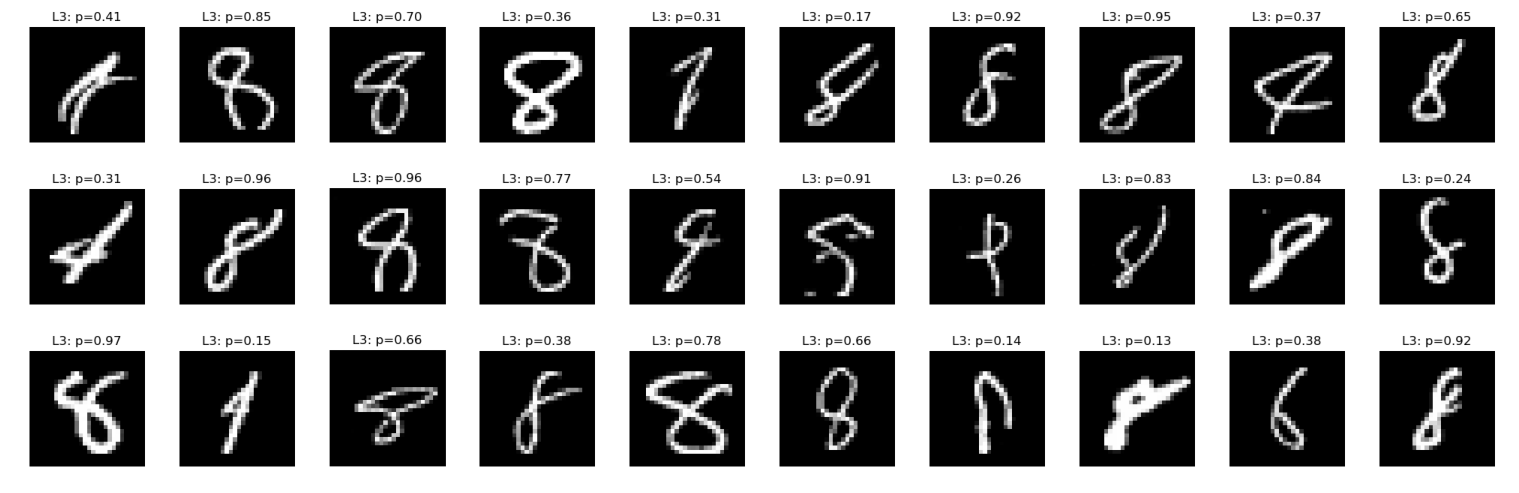

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 4


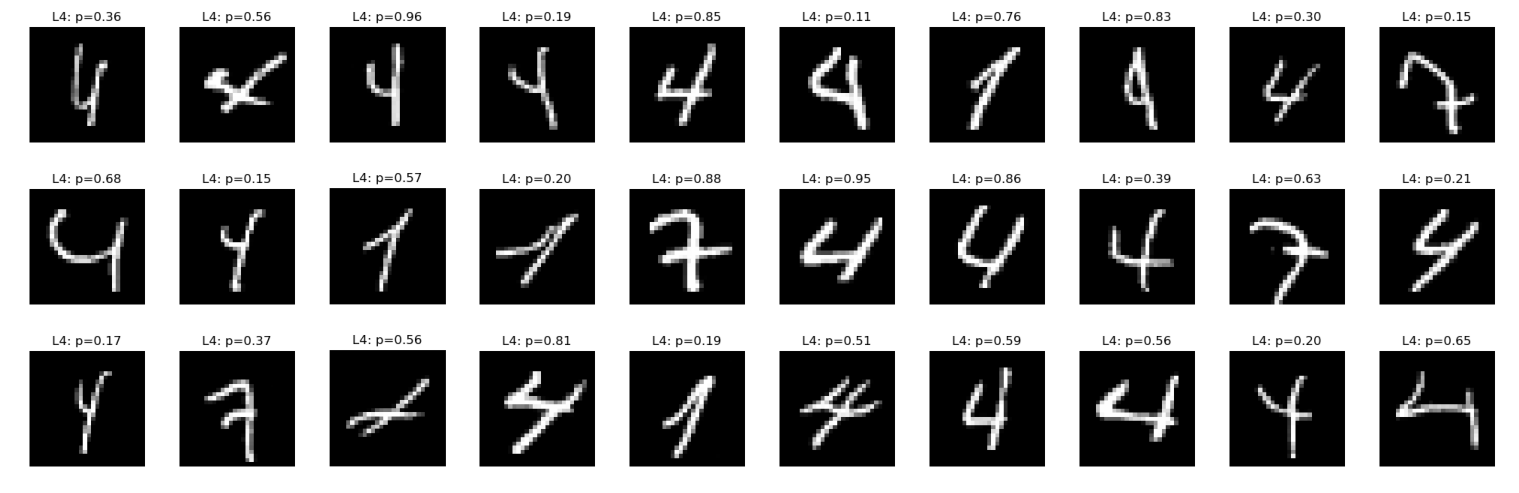

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 5


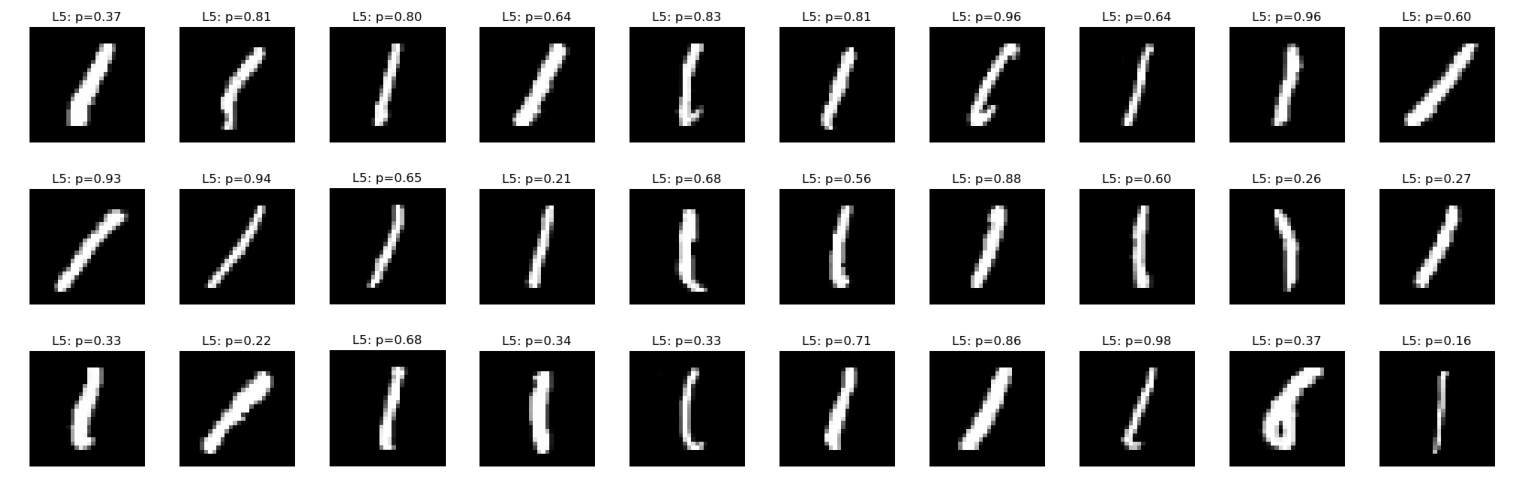

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 6


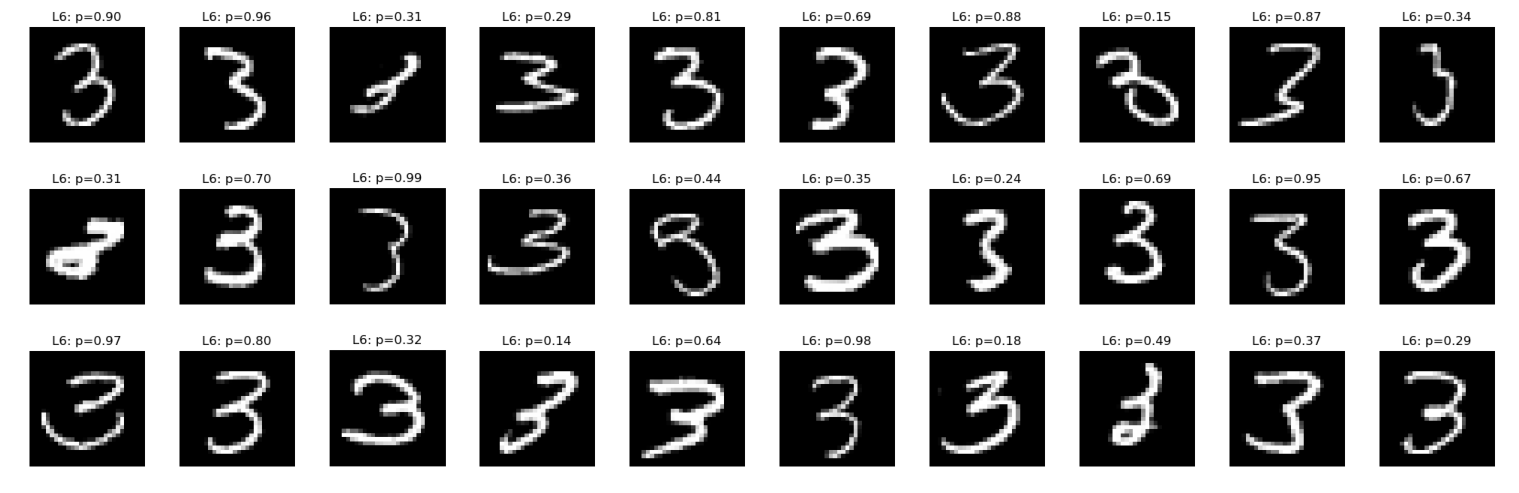

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 7


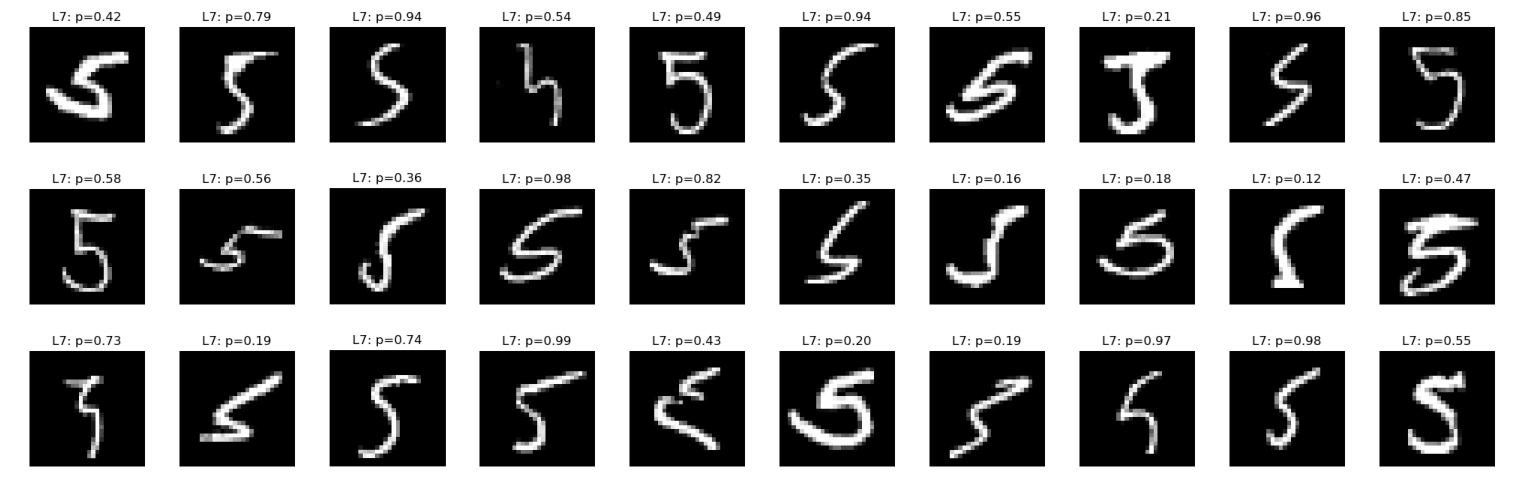

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 8


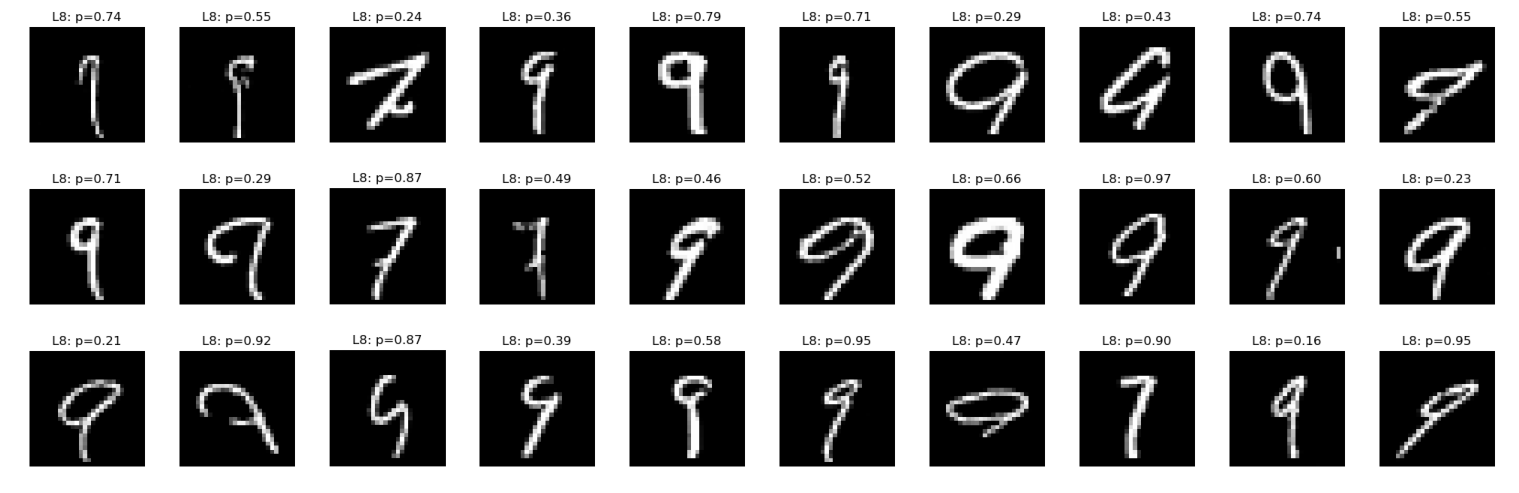

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 9


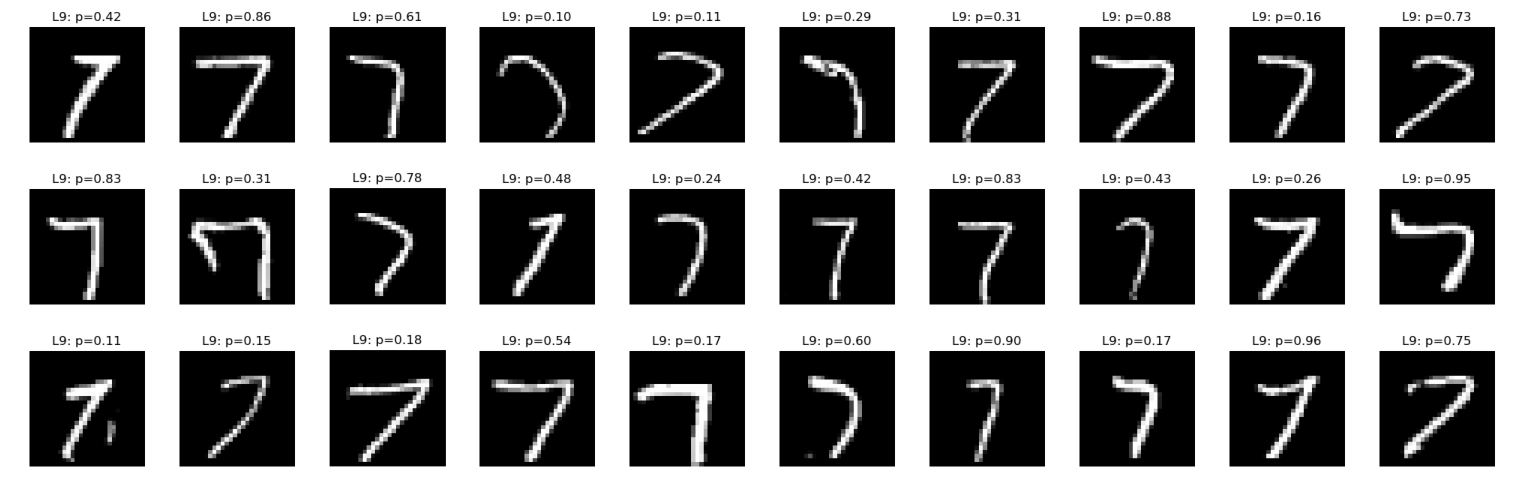

------------------------------------------------------------------------------------------------------------------------------------------------------


In [93]:
for cluster_id in range(max_cluster_id+1):
    print(f"cluster_id {cluster_id}")
    img_dir = f"img_cluster_{cluster_id}"
    
    # get all filenames
    img_filenames = []
    for filename in os.listdir(f"../from_cluster/results_all_leaves/{dataset}/seed_1/ddpm/sample_all_l/{img_dir}"):
        if filename.startswith("output_"):
            img_filenames.append(filename)
        
    # only consider files with probs > 0.1
    probs = []
    for filename in img_filenames:
        probs.append(float(filename.split("_")[-1].split(".png")[0]))

    probs = np.array(probs)
    img_filenames = np.array(img_filenames)[probs > 0.1]
    
    # display 30 random images in a 10x3 grid
    plt.figure(figsize=(15,5))

    for i in range(len(img_filenames)):
        if i == 30:
            break
        plt.subplot(3,10,i+1)
        img = mpimg.imread(os.path.join(f"../from_cluster/results_all_leaves/{dataset}/seed_1/ddpm/sample_all_l/{img_dir}", img_filenames[i]))
        plt.imshow(img)
        plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

    print(150*"-")


# Clusters with images regardless of probabilities 

In [94]:
# get max rank
max_rank = 0
for filename in os.listdir(ddpm_samples_dir):
    if filename.startswith("output__"):
        rank = int(filename.split("_")[2])
        if rank > max_rank:
            max_rank = rank

# get max batch idx
max_batch_idx = 0
for filename in os.listdir(ddpm_samples_dir):
    if filename.startswith("output__"):
        batch_idx = int(filename.split("_")[3].split(".")[0])
        if batch_idx > max_batch_idx:
            max_batch_idx = batch_idx

# get max sample idx
max_sample_idx = 0
for filename in os.listdir(ddpm_samples_dir):
    if filename.startswith("output__"):
        sample_idx = int(filename.split("_")[4].split(".")[0])
        if sample_idx > max_sample_idx:
            max_sample_idx = sample_idx


print(max_rank, max_batch_idx, max_sample_idx)

0 39 255


cluster_id 0


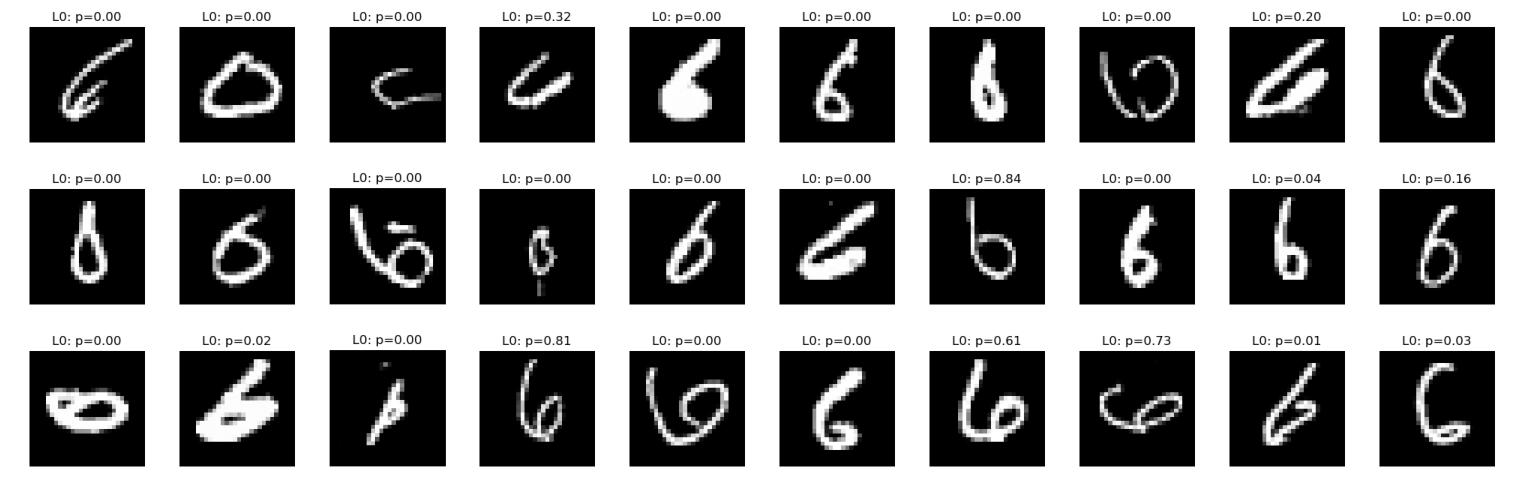

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 1


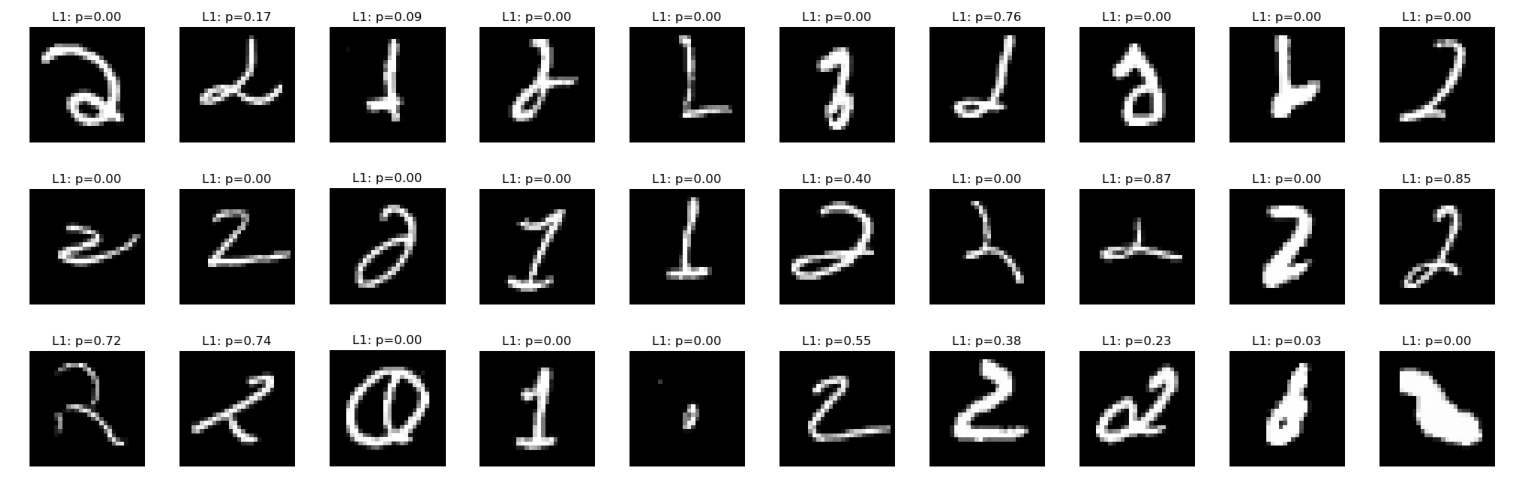

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 2


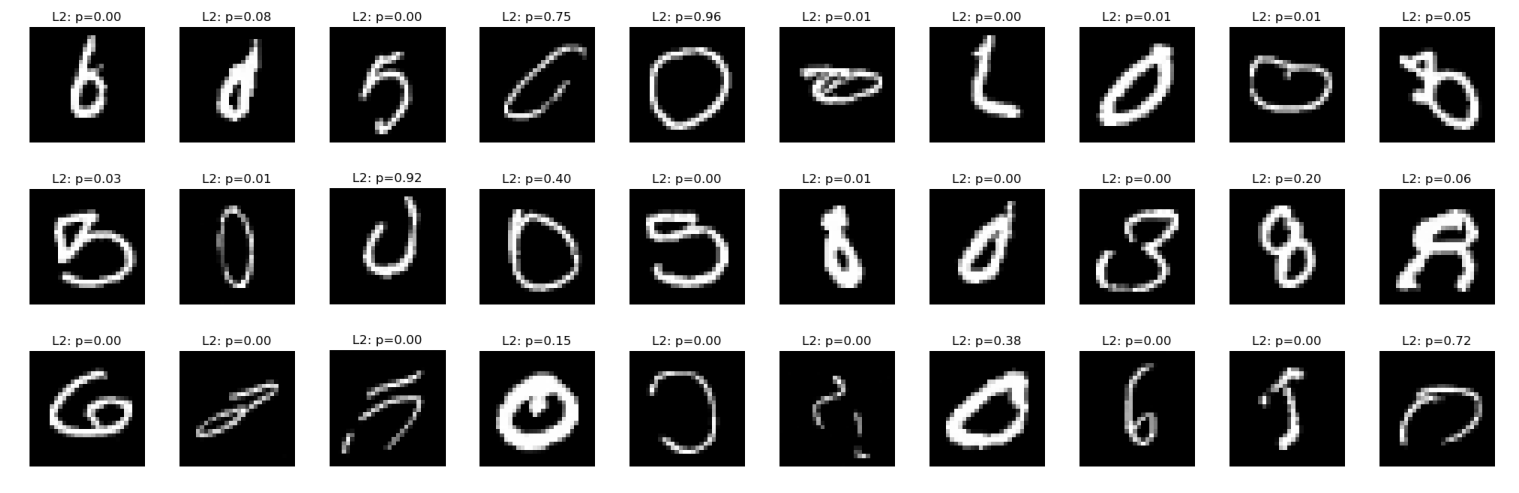

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 3


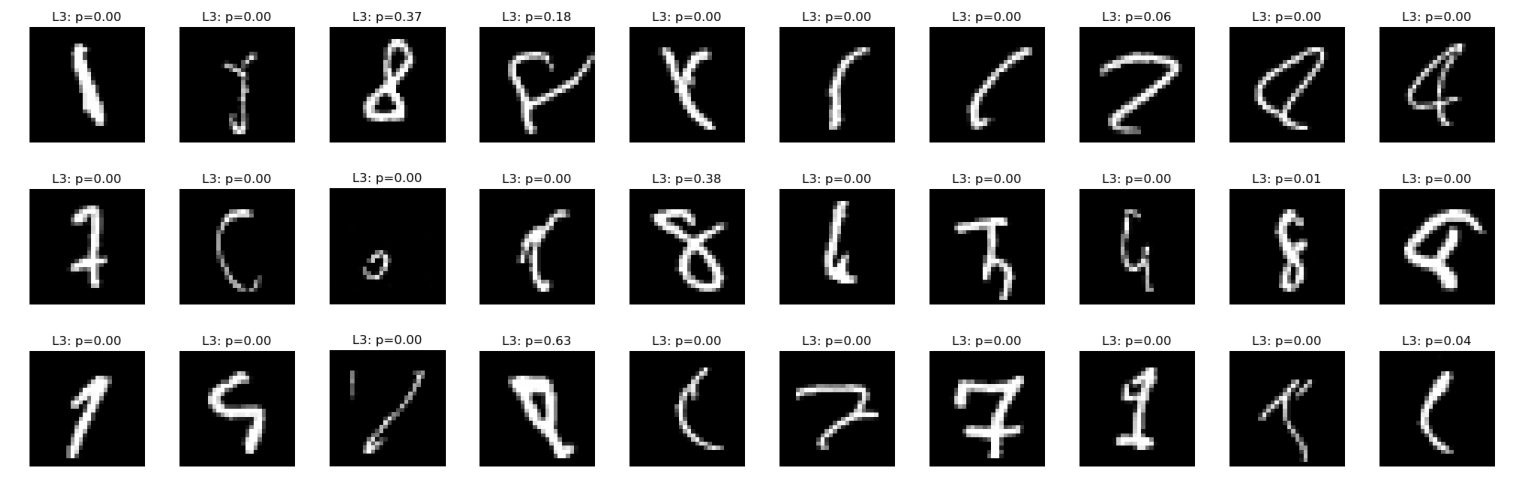

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 4


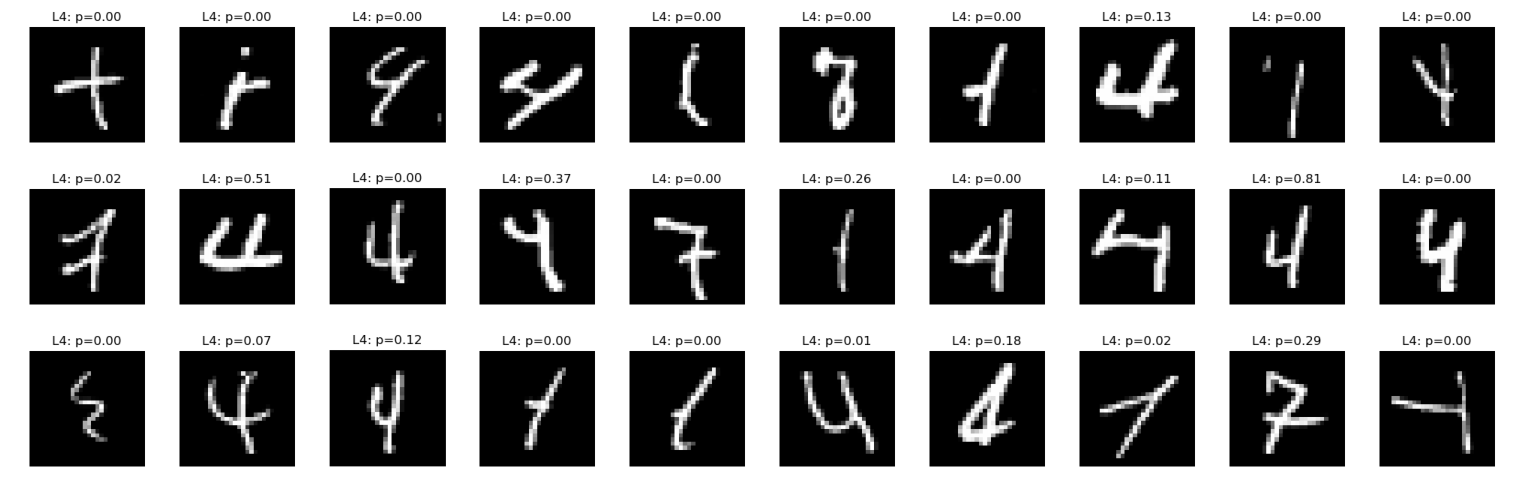

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 5


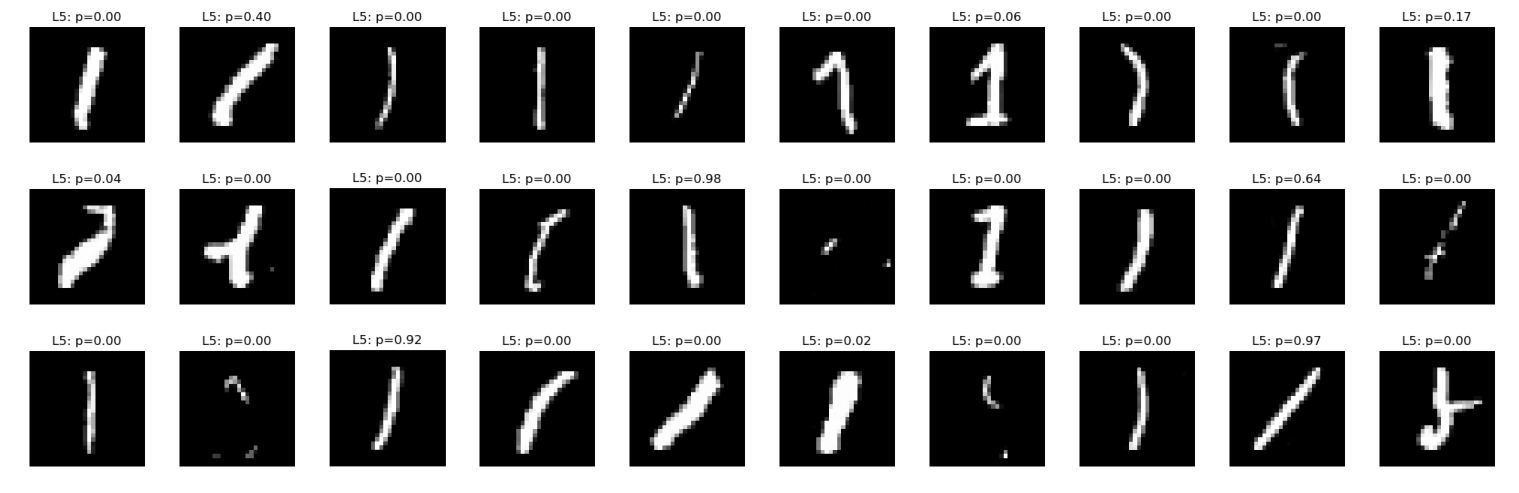

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 6


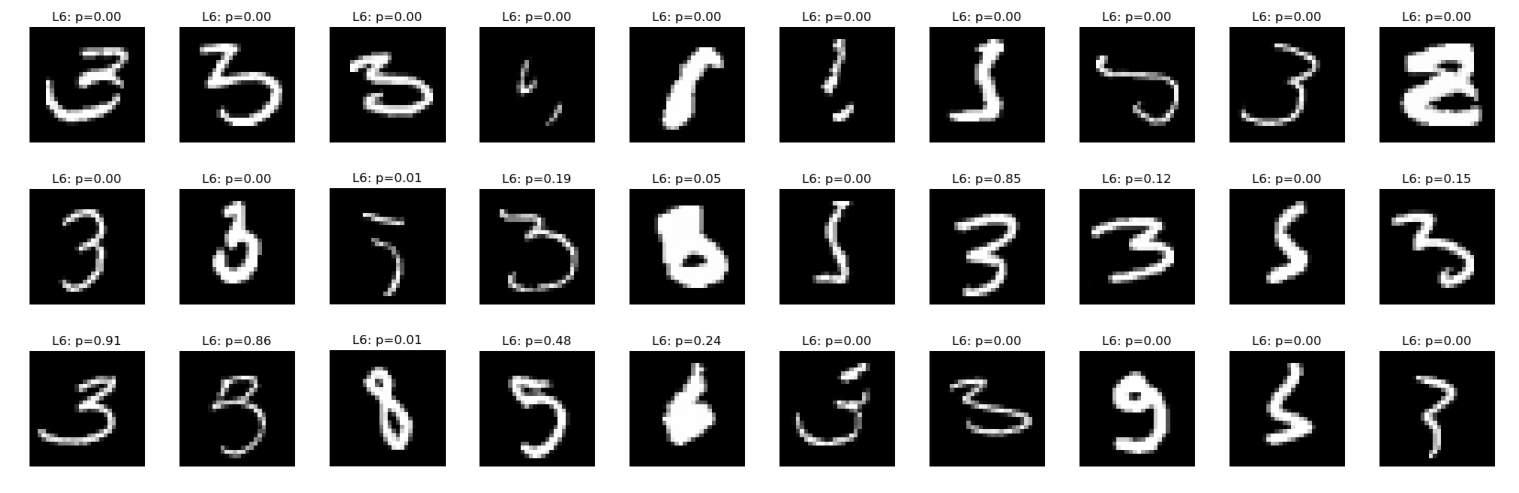

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 7


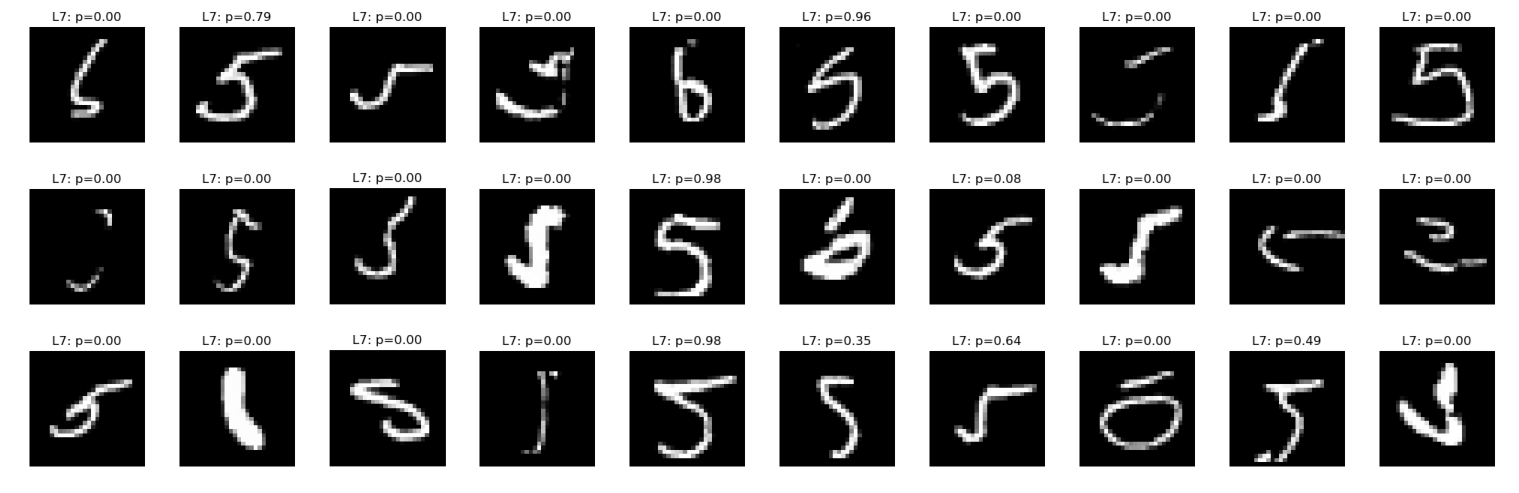

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 8


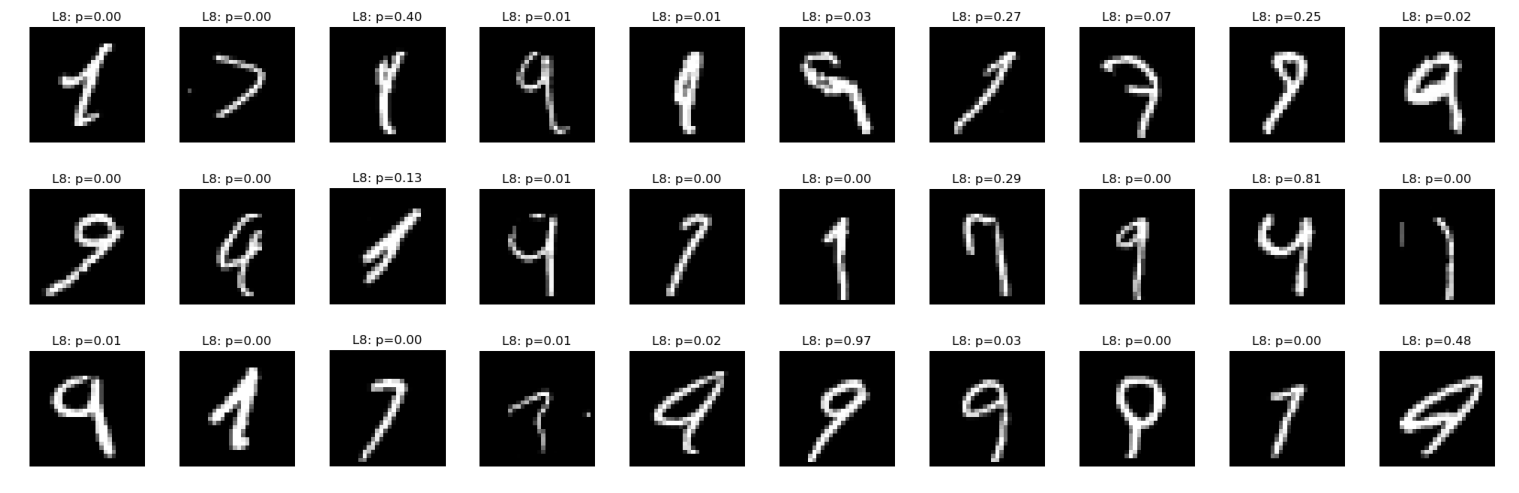

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 9


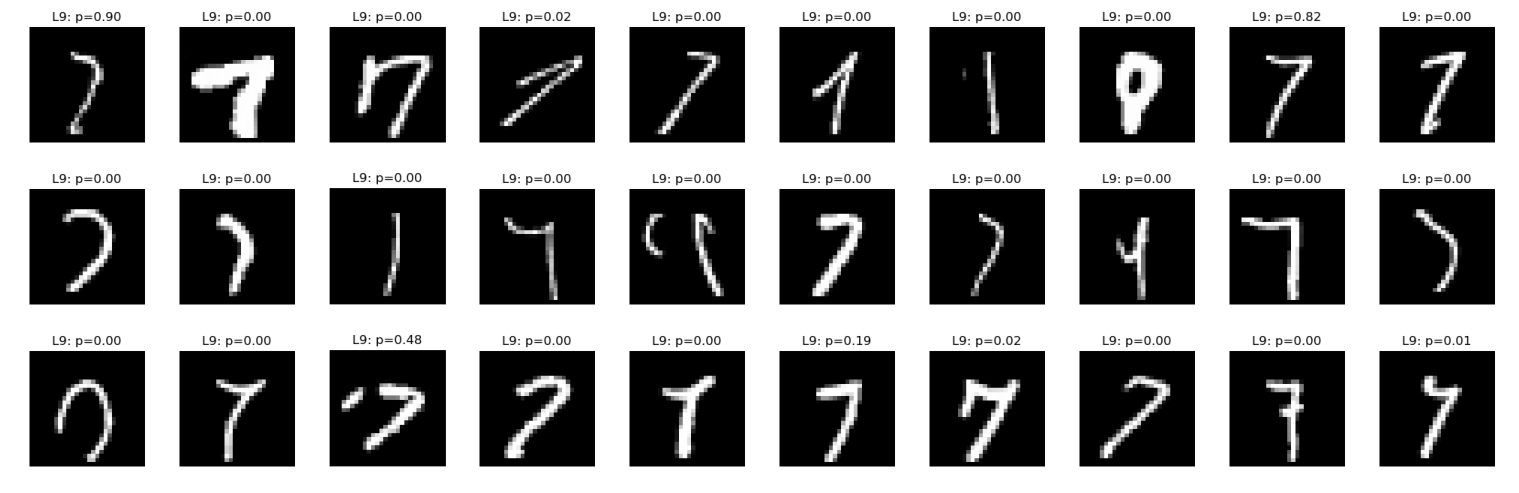

------------------------------------------------------------------------------------------------------------------------------------------------------


In [95]:
# show 30 random images from the "results/ddpm/images/img_cluster_{cluster_id}/" folder

for cluster_id in range(max_cluster_id+1):
    print(f"cluster_id {cluster_id}")
    img_dir = f"img_cluster_{cluster_id}"
    
    # get 30 random batch_idx from range(0, max_batch_idx)
    batch_idx_list = np.random.choice(range(max_batch_idx), 30, replace=True)
    sample_idx_list = np.random.choice(range(max_sample_idx), 30, replace=False)

    # display 30 random images in a 10x3 grid
    plt.figure(figsize=(15,5))

    for i, batch_idx in enumerate(batch_idx_list):
        filename_start = f"output__0_{batch_idx}_{sample_idx_list[i]}"
        # get filename that starts with filename_start
        filename = [filename for filename in os.listdir(os.path.join(ddpm_samples_dir, img_dir)) if filename.startswith(filename_start)][0]
        # get probability from filename "{filename_start}_{prob}.png"
        prob = filename.split("_")[-1].split(".png")[0]
        prob = float(prob)

        img = mpimg.imread(os.path.join(ddpm_samples_dir, img_dir, filename))
        plt.subplot(3, 10, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout(pad=0)
    plt.show()

    print(150*"-")


# Prediction distribution for a pretrained cifar10 model on the clusters

In [84]:
# lead all images from "results/ddpm/images/img_cluster_{cluster_id}/" folder

cluster_id = 0

img_dir = f"img_cluster_{cluster_id}"

# get all filenames
img_filenames = []
for filename in os.listdir(f"../from_cluster/results_all_leaves/{dataset}/seed_1/ddpm/sample_all_l/{img_dir}"):
    if filename.startswith("output_"):
        img_filenames.append(filename)



Need to cut image and rescale it accordingly to retrieve a cifar10 image

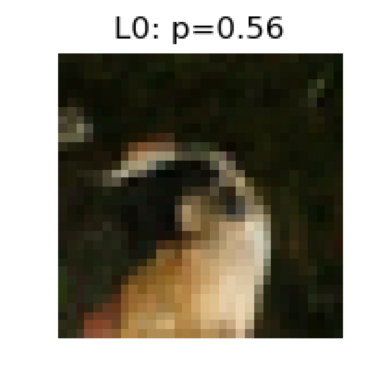

In [85]:
# print first image
img = mpimg.imread(os.path.join(ddpm_samples_dir, img_dir, img_filenames[0]))
plt.imshow(img)
plt.axis("off")
plt.show() 

(154, 154, 3)

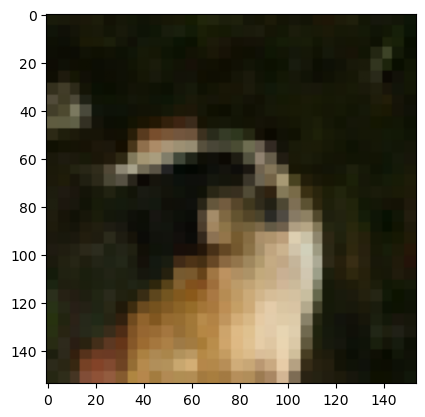

In [86]:
# only show center of image

img_center = img[24:178, 26:180, 0:3]
plt.imshow(img_center)

img_center.shape

In [87]:
import torch
import torchvision
import yaml
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from utils.data_utils import get_data, get_gen



In [52]:
# cut every image by [24:178, 26:180, :], rescale to 32x32 and save as dataset

class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.img_filenames = []
        for filename in os.listdir(self.img_dir):
            if filename.startswith("output_"):
                self.img_filenames.append(filename)
        self.transform = transform

    def __len__(self):
        return len(self.img_filenames)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.img_filenames[idx]))
        img = np.array(img)
        img = img[24:178, 26:180, 0:3]
        img = Image.fromarray(img)
        img = img.resize((32,32))
        if self.transform:
            img = self.transform(img)
        return img
    
    
test_dataset = ImageDataset(f"../from_cluster/results_all_leaves/{dataset}/seed_1/ddpm/sample_all_l/{img_dir}", transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


# use a pretrained model to train a solid cifar10 classificator

In [54]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config_dict = yaml.safe_load(f)
    config = OmegaConf.create(config_dict)
    return config

model_path = "models/experiments/" + dataset + ex_name

with open(model_path + "/config.yaml", 'r') as stream:
        configs = yaml.load(stream,Loader=yaml.Loader)

# Dataset
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()
    

In [55]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.optim as optim
import numpy as np
from tqdm import tqdm


In [56]:
device = torch.device('cpu')

# Load pre-trained ResNet50 Model
model = models.resnet50(pretrained=True)
# Freeze all layers except the final classification layer
for param in model.parameters():
    param.requires_grad = False
    
# Change the final layer of ResNet50 Model for Transfer Learning
model.fc = nn.Sequential(
                nn.Linear(2048, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, 10))

# Move model to GPU
model = model.to(device)

# Set model to training mode
model.train()


# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10
total_step = len(gen_train)
for epoch in tqdm(range(num_epochs)):
    for i, (images, labels) in enumerate(gen_train):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
                         
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        


/opt/anaconda3/envs/treevae2/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/treevae2/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  0%|          | 0/10 [00:01<?, ?it/s]


RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[256, 1, 28, 28] to have 3 channels, but got 1 channels instead

In [97]:
# Test the model
model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in gen_test:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted.cpu() == labels.cpu()).sum().item()

    print(f'Accuracy of the model on the {len(gen_test)} test images: {100 * correct / total}%')


AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

In [102]:
# load pre-trained model from classifier_pretraining/resnet50_cifar10.pth

model.load_state_dict(torch.load("classifier_pretraining/resnet50_cifar10.pth"))

AttributeError: 'collections.OrderedDict' object has no attribute 'load_state_dict'

In [21]:
# get max cluster_id from the "results/ddpm/images/img_cluster_{cluster_id}/" folder

max_cluster_id = 0

for filename in os.listdir(f"../from_cluster/results_all_leaves/cifar10/seed_1/ddpm/sample_all_l/"):
    if filename.startswith("img_cluster_"):
        cluster_id = int(filename.split("_")[2])
        if cluster_id > max_cluster_id:
            max_cluster_id = cluster_id

cluster_id 0


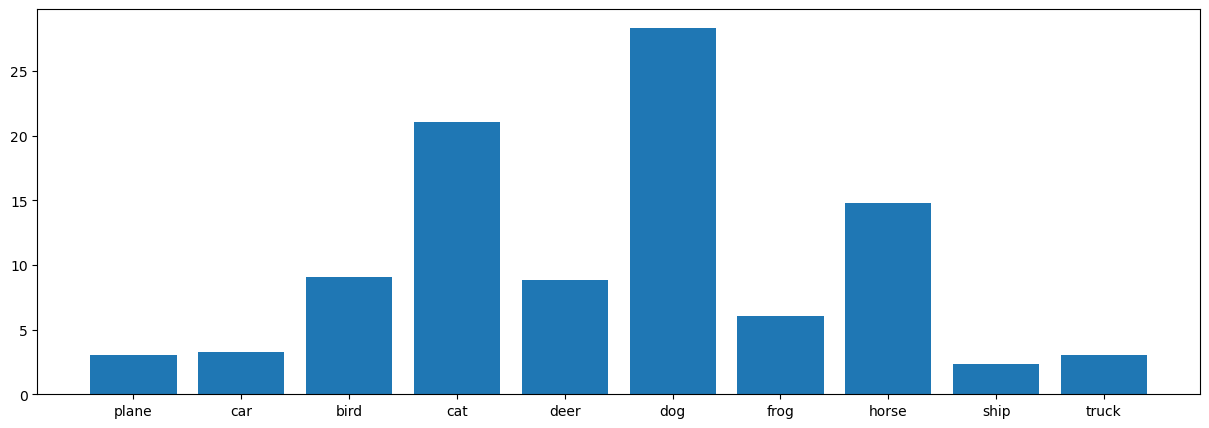

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 1


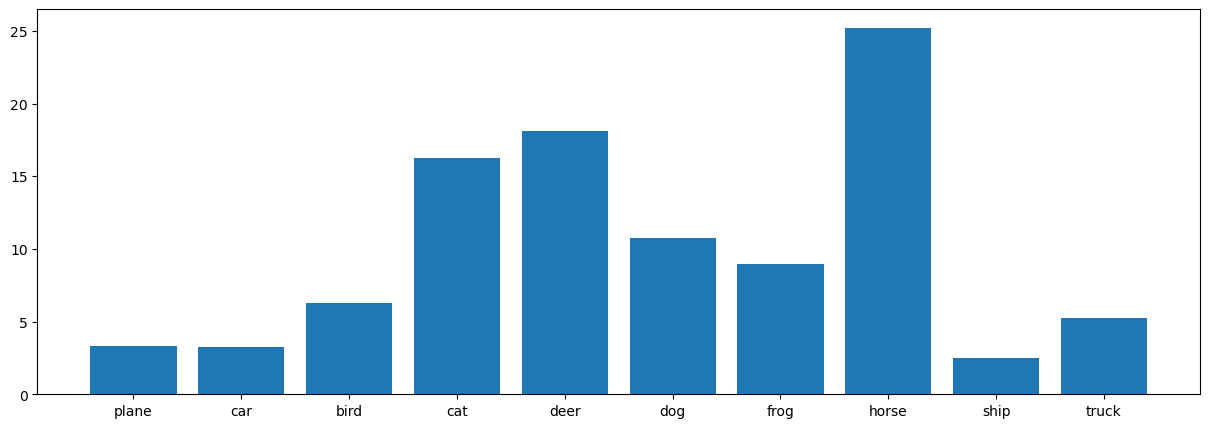

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 2


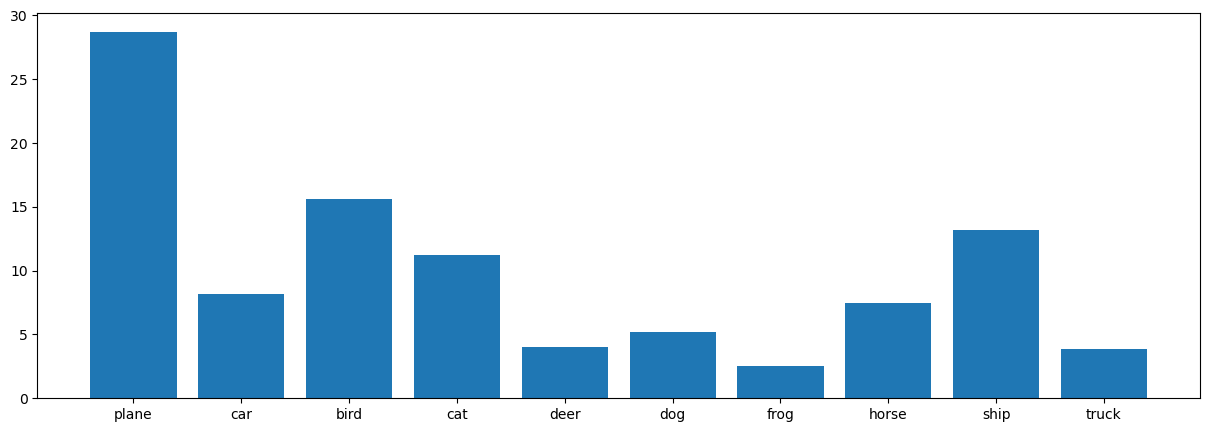

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 3


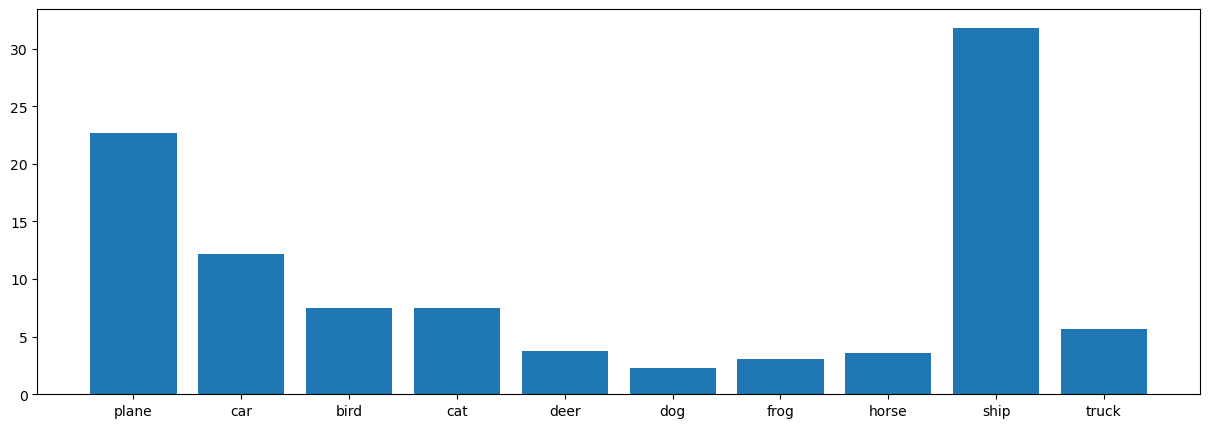

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 4


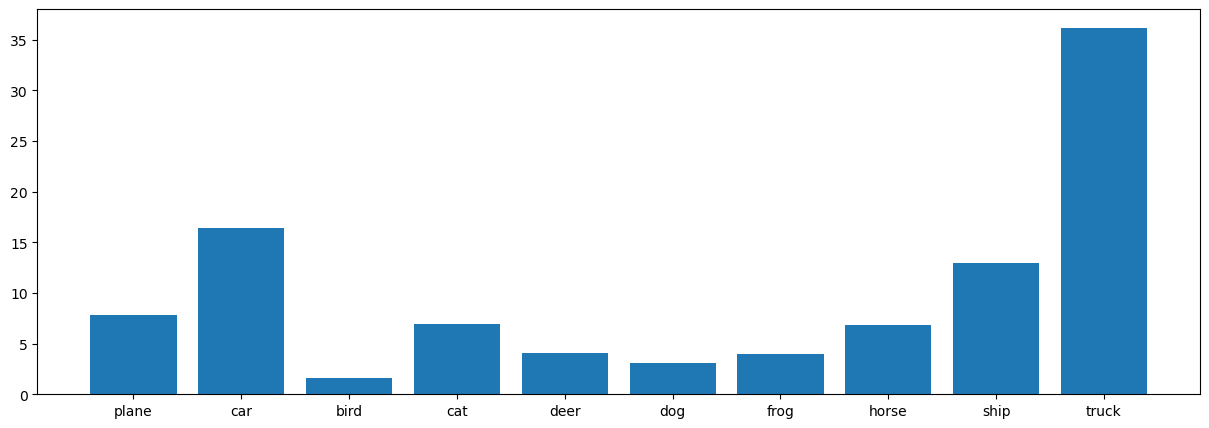

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 5


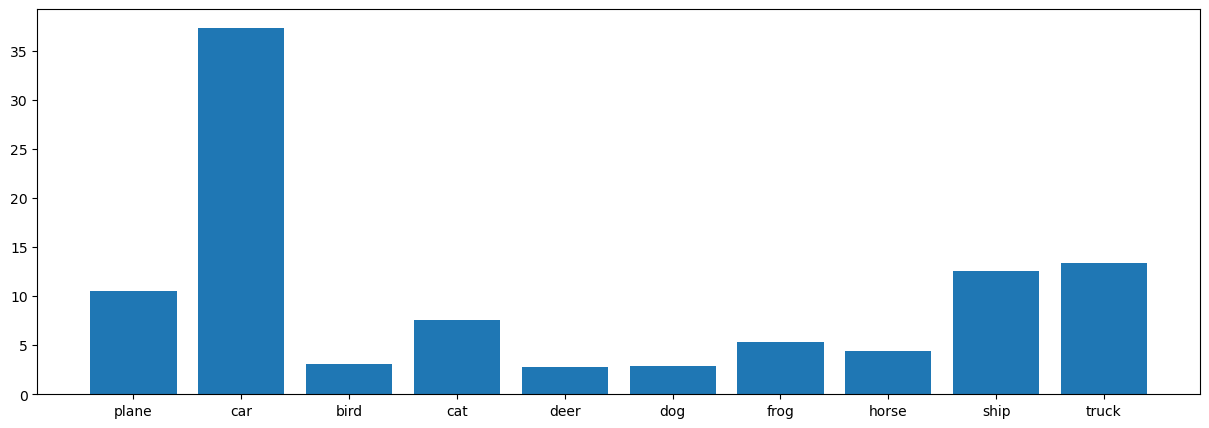

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 6


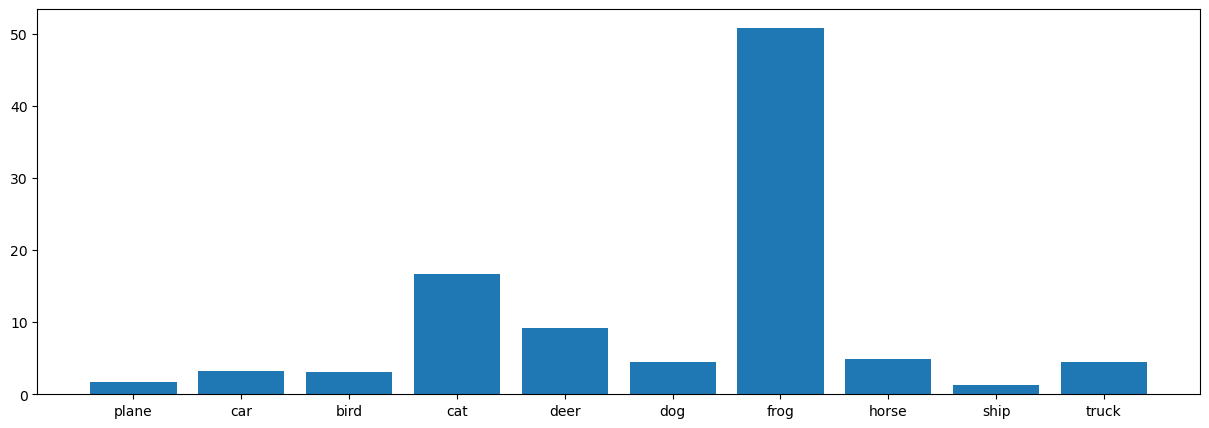

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 7


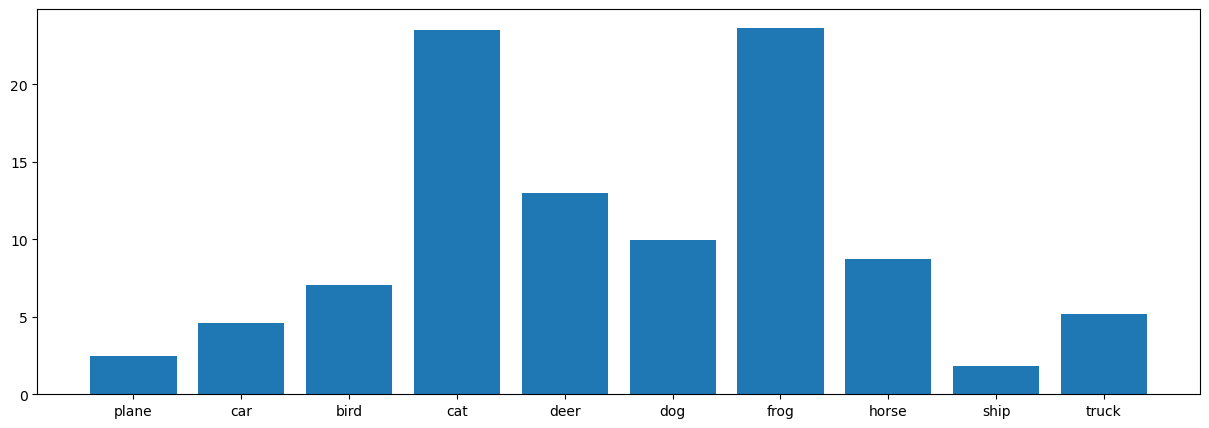

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 8


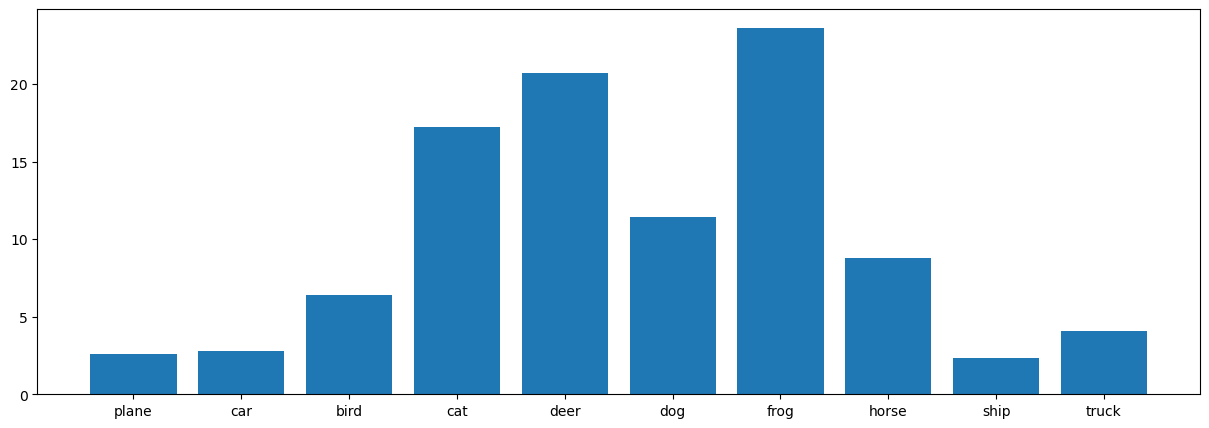

------------------------------------------------------------------------------------------------------------------------------------------------------
cluster_id 9


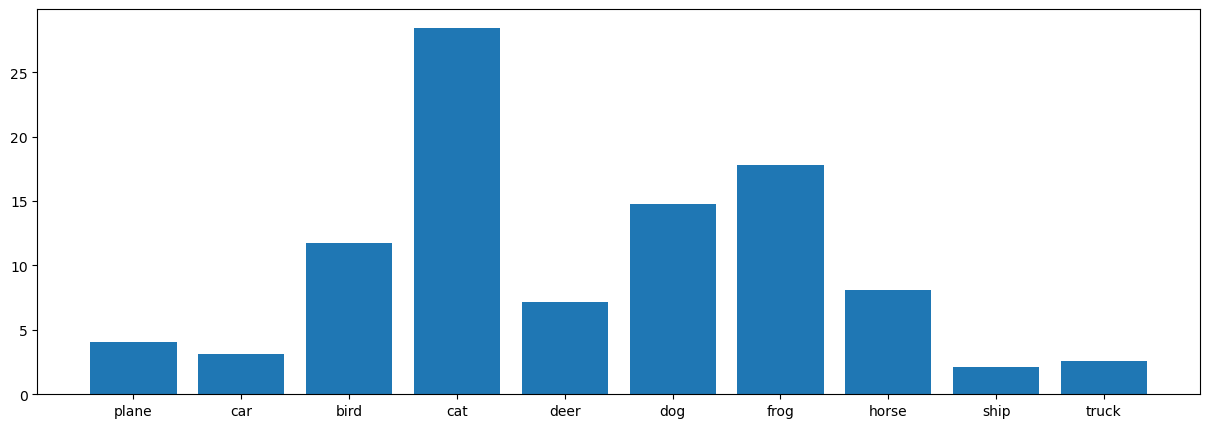

------------------------------------------------------------------------------------------------------------------------------------------------------


In [23]:
# for each cluster in "results/ddpm/images/img_cluster_{cluster_id}/" folder,
# plot percentage of each class

# rows are clusters, columns are predicted classes
confusion_matrix = np.zeros((10,10))

for cluster_id in range(max_cluster_id+1):

    print(f"cluster_id {cluster_id}")

    img_dir = f"img_cluster_{cluster_id}"
    test_dataset = ImageDataset(f"../from_cluster/results_all_leaves/cifar10/seed_1/ddpm/sample_all_l/{img_dir}", transform=transforms.ToTensor())
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    model.eval()

    with torch.no_grad():
        y_pred = []
        for images in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_pred.append(predicted.cpu().numpy()[0])
        y_pred = np.array(y_pred)

        # add to confusion matrix for each cluster row
        confusion_matrix[cluster_id] = [100 * np.sum(y_pred == i) / len(y_pred) for i in range(10)]

    # add names of classes
    classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

    # plot percentage of each class
    plt.figure(figsize=(15,5))
    plt.bar(classes, confusion_matrix[cluster_id])
    plt.xticks()
    plt.show()
    
    print(150*"-")

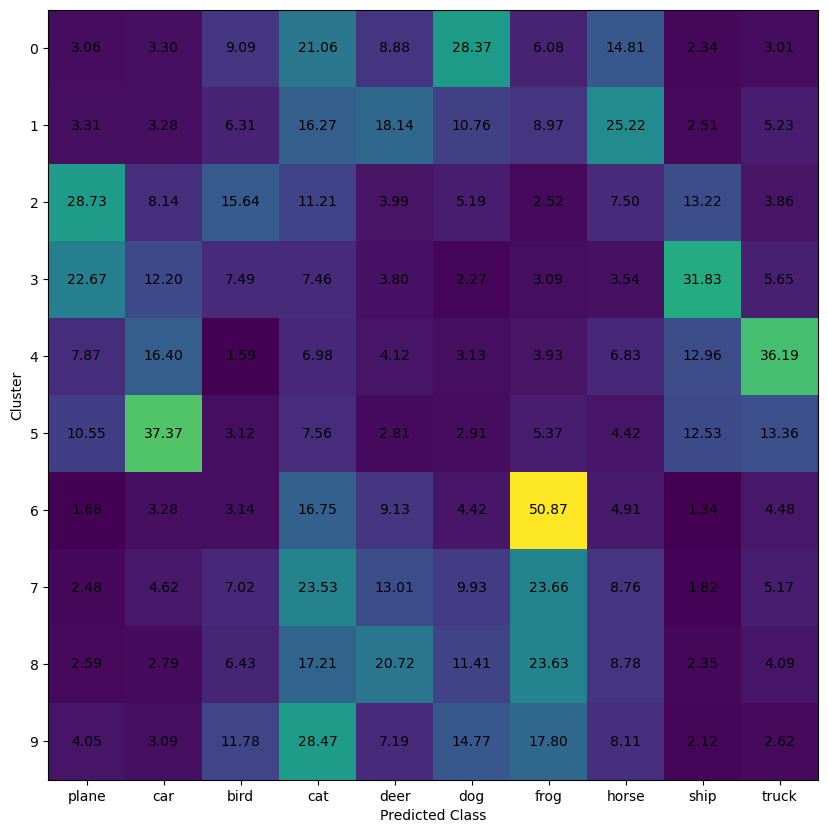

In [33]:

# add percentage of each class in each cell

plt.figure(figsize=(10,10))
for i in range(10):
    for j in range(max_cluster_id+1):
        plt.text(i, j, f"{confusion_matrix[j,i]:.2f}", ha='center', va='center', color='black')
plt.imshow(confusion_matrix, cmap='viridis')
plt.xticks(range(10), classes)
plt.yticks(range(max_cluster_id+1))
plt.xlabel("Predicted Class")
plt.ylabel("Cluster")
plt.show()

